In [2]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.4.0


# MIMO Imaging Radar

A MIMO array with $N_{TX}$ transmitters and $N_{RX}$ receivers synthesizes a **virtual aperture** of $N_{TX} \times N_{RX}$ elements:

$$D_{virtual} = D_{TX} + D_{RX}, \qquad \Delta\theta \approx \frac{\lambda}{D_{virtual}}$$

This dramatically improves angular resolution over a phased array of the same element count. Each transmitter uses an **orthogonal waveform** (TDM, FDM, or CDM) so its contribution can be separated at every receiver.

### This Example

- **Radar**: 60.5 GHz (V-band), 1 GHz BW → ΔR = 15 cm
- **Array**: 64 TX × 128 RX → 8 192 virtual channels, virtual 64×128 aperture
- **Targets**: Half-ring + two 1 m spheres at 20 m range, separated by 2 m in cross-range
- **Processing**: Range FFT → 1D OS-CFAR → 2D angular FFT (1024×1024) → max-projection image

## Configure MIMO Array

### Import Required Modules

In [3]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### MIMO Array Design

The physical arrays are positioned so their convolution produces a **uniform virtual array**:

$$\text{Virtual positions} = \text{TX positions} \otimes \text{RX positions}$$

| Sub-array | Elements | Axis | Role |
|-----------|----------|------|------|
| TX group 1 | 32 | Z (vertical) | First TX sub-array |
| TX group 2 | 32 | Z (vertical) | Second TX sub-array (y-offset) |
| RX group 1 | 64 | Y (horizontal) | Bottom z-position |
| RX group 2 | 64 | Y (horizontal) | Top z-position |

With λ/2 virtual element spacing and 128 virtual elements: $\Delta\theta \approx \lambda / (64\lambda) \approx 0.9°$ at 60.5 GHz.

In [4]:
# Calculate wavelength for 60.5 GHz
wavelength = 3e8 / 60.5e9  # λ ≈ 4.96 mm

# Define array dimensions
N_tx = 64   # Total transmitters (2 groups of 32)
N_rx = 128  # Total receivers (2 groups of 64)

# Initialize transmitter channel list
tx_channels = []

# First transmitter sub-array (32 elements)
# Positioned along z-axis, offset in y
for idx in range(0, int(N_tx / 2)):
    tx_channels.append(
        dict(
            location=(
                0,  # x-position: at origin
                -N_rx / 2 * wavelength / 4,  # y-position: offset for virtual array
                wavelength * idx - (N_tx / 2 - 1) * wavelength / 2,  # z-position: vertical
            ),
        )
    )

# Second transmitter sub-array (32 elements)
# Positioned along z-axis, different y offset
for idx in range(0, int(N_tx / 2)):
    tx_channels.append(
        dict(
            location=(
                0,  # x-position: at origin
                wavelength * N_rx / 4 - N_rx / 2 * wavelength / 4,  # y-position: different offset
                wavelength * idx - (N_tx / 2 - 1) * wavelength / 2,  # z-position: vertical
            ),
        )
    )

# Initialize receiver channel list
rx_channels = []

# First receiver sub-array (64 elements)
# Positioned along y-axis (horizontal), at bottom z-position
for idx in range(0, int(N_rx / 2)):
    rx_channels.append(
        dict(
            location=(
                0,  # x-position: at origin
                wavelength / 2 * idx - (N_rx / 2 - 1) * wavelength / 4,  # y-position: horizontal
                -(N_tx / 2) * wavelength / 2,  # z-position: bottom
            ),
        )
    )

# Second receiver sub-array (64 elements)
# Positioned along y-axis (horizontal), at top z-position
for idx in range(0, int(N_rx / 2)):
    rx_channels.append(
        dict(
            location=(
                0,  # x-position: at origin
                wavelength / 2 * idx - (N_rx / 2 - 1) * wavelength / 4,  # y-position: horizontal
                wavelength * (N_tx / 2) - (N_tx / 2) * wavelength / 2,  # z-position: top
            ),
        )
    )

### Transmitter and Receiver

| Parameter | Value | Notes |
|-----------|-------|-------|
| Frequency | 61–60 GHz (down-chirp) | 1 GHz BW, ΔR = 15 cm |
| Chirp duration | 16 µs | |
| TX power | 15 dBm / channel | |
| PRP | 40 µs | |
| Pulses | 1 | Single snapshot |
| Sampling rate | 20 MHz | R_max ≈ 240 m |
| Noise figure | 8 dB | |
| RF + BB gain | 20 + 30 dB | |

In [5]:
# Configure FMCW transmitter
tx = Transmitter(
    f=[61e9, 60e9],    # Frequency sweep: 61-60 GHz (1 GHz bandwidth, down-chirp)
    t=[0, 16e-6],      # Chirp duration: 0-16 μs
    tx_power=15,       # Transmit power: 15 dBm per channel
    prp=40e-6,         # Pulse repetition period: 40 μs
    pulses=1,          # Single chirp (imaging snapshot)
    channels=tx_channels  # MIMO transmit array
)

# Configure receiver
rx = Receiver(
    fs=20e6,           # Sampling rate: 20 MHz
    noise_figure=8,    # Noise figure: 8 dB
    rf_gain=20,        # RF gain: 20 dB
    load_resistor=500, # Load resistance: 500 Ω
    baseband_gain=30,  # Baseband gain: 30 dB
    channels=rx_channels,  # MIMO receive array
)

# Create complete MIMO imaging radar system
radar = Radar(transmitter=tx, receiver=rx)

### Visualize Array Layout

Physical TX (red) and RX (blue) positions, normalized by wavelength. Their convolution forms the dense virtual aperture used for imaging.

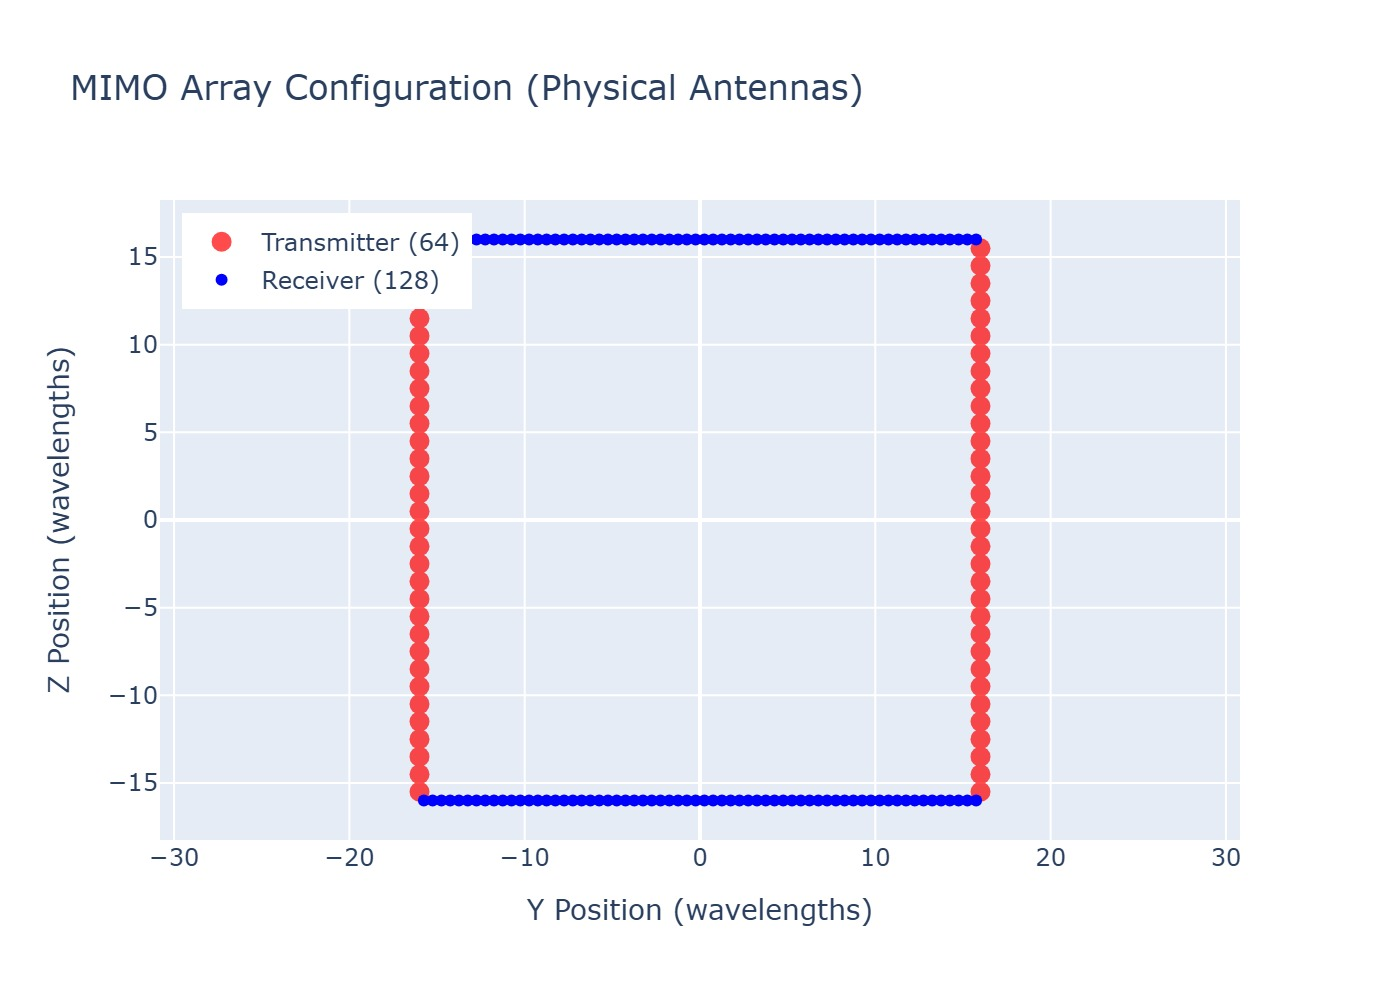

In [6]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=radar.radar_prop["transmitter"].txchannel_prop["locations"][:, 1] / wavelength,
        y=radar.radar_prop["transmitter"].txchannel_prop["locations"][:, 2] / wavelength,
        mode="markers",
        name="Transmitter (64)",
        opacity=0.7,
        marker=dict(size=10, color="red"),
    )
)

fig.add_trace(
    go.Scatter(
        x=radar.radar_prop["receiver"].rxchannel_prop["locations"][:, 1] / wavelength,
        y=radar.radar_prop["receiver"].rxchannel_prop["locations"][:, 2] / wavelength,
        mode="markers",
        opacity=1,
        name="Receiver (128)",
        marker=dict(size=6, color="blue"),
    )
)

fig.update_layout(
    title="MIMO Array Configuration (Physical Antennas)",
    height=500,
    xaxis=dict(title="Y Position (wavelengths)"),
    yaxis=dict(title="Z Position (wavelengths)", scaleanchor="x", scaleratio=1),
    legend=dict(x=0.02, y=0.98),
)

show(fig)

## Target Scene

Three objects placed at 20 m range, separated in cross-range to test angular resolution:

| Target | Model | Y offset | Z offset | Notes |
|--------|-------|----------|----------|-------|
| Half-ring | `torus_half.stl` | 0 m | 0 m | Main structure |
| Sphere 1 | `sphere_1m.stl` | −1 m | +1 m | Angular separation ≈ 5.7° |
| Sphere 2 | `sphere_1m.stl` | +1 m | +1 m | Angular separation ≈ 5.7° |

The two spheres subtend roughly 5.7° (2 m at 20 m), just above the ~0.9° per-axis angular resolution, so they appear as clearly distinct spots in the final image.

In [7]:
# Target 1: Half-ring structure (extended target)
target_1 = {
    "model": "../models/half_ring.stl",  # Complex curved geometry
    "unit": "m",                          # Model units in meters
    "location": (20, 0, 0),              # Position: 20m range, centered
    "speed": (0, 0, 0),                  # Stationary target
    "rotation": (0, 0, 0),               # No rotation
}

# Target 2: Sphere at left position
ball_1 = {
    "model": "../models/ball_1m.stl",    # 1m diameter sphere
    "unit": "m",                          # Model units in meters
    "location": (20, -1, -1),            # Position: 20m range, -1m Y, -1m Z
    "speed": (0, 0, 0),                  # Stationary
    "rotation": (0, 0, 0),               # No rotation
}

# Target 3: Sphere at right position
ball_2 = {
    "model": "../models/ball_1m.stl",    # 1m diameter sphere
    "unit": "m",                          # Model units in meters
    "location": (20, 1, -1),             # Position: 20m range, +1m Y, -1m Z
    "speed": (0, 0, 0),                  # Stationary
    "rotation": (0, 0, 0),               # No rotation
}

# Combine targets for simulation
targets = [target_1, ball_1, ball_2]

### Visualize Target Scene

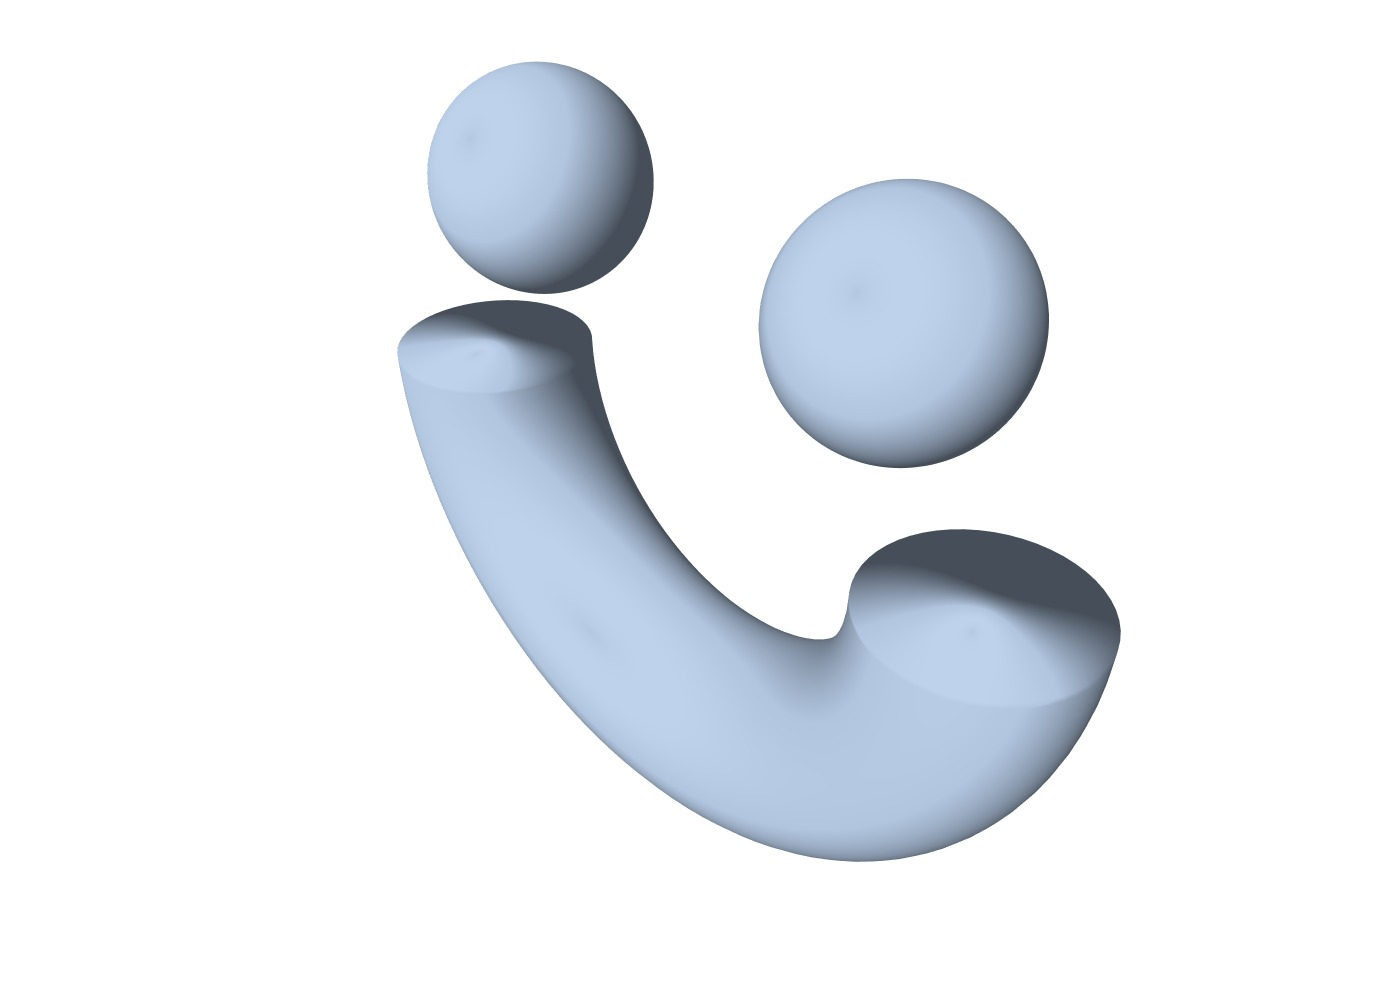

In [8]:
import pymeshlab

def load_mesh(model_path, y_offset=0, z_offset=0, name=""):
    ms = pymeshlab.MeshSet()
    ms.load_new_mesh(model_path)
    t_mesh = ms.current_mesh()
    v = np.array(t_mesh.vertex_matrix())
    f = np.array(t_mesh.face_matrix())
    return go.Mesh3d(
        x=v[:, 0],
        y=v[:, 1] + y_offset,
        z=-v[:, 2] + z_offset,
        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],
        color="lightsteelblue",
        flatshading=False,
        lighting=dict(ambient=0.4, diffuse=0.9, specular=0.3, roughness=0.5),
        lightposition=dict(x=1000, y=500, z=1000),
        name=name,
    )

fig = go.Figure()
fig.add_trace(load_mesh(target_1["model"], name="Half Ring"))
fig.add_trace(load_mesh(ball_1["model"], y_offset=-1, z_offset=1, name="Sphere 1"))
fig.add_trace(load_mesh(ball_2["model"], y_offset=1, z_offset=1, name="Sphere 2"))

fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
    ),
    height=500,
    margin=dict(l=0, r=0, b=0, t=0),
)

show(fig)

## Run Simulation

Each of the 64 TX channels transmits in sequence (TDM), and all 128 RX channels sample simultaneously. The simulator returns a `[samples × pulses × channels]` array — here `[8192 × 1 × 320]` — where 320 = 64 TX × 5 RX sub-arrays per TX.

> **Note**: This simulation is computationally intensive due to the 8 192 virtual channels and 3D mesh targets.

In [9]:
# Import radar simulator and timing module
from radarsimpy.simulator import sim_radar
import time

# Start timing
tic = time.time()

# Simulate MIMO radar returns from multi-target scene
# density=0.3: Ray tracing density for complex geometry
data = sim_radar(radar, targets, density=0.3)

# Extract baseband I/Q signals and add system noise
baseband = data["baseband"] + data["noise"]  # Complex samples [8192, 1, 320]

# End timing
toc = time.time()

# Display execution time
print("Exec time:", toc - tic, "s")

Exec time: 65.70083928108215 s


## Signal Processing

The processing pipeline:

1. **Range FFT**: Apply Hann window, zero-pad to 8 192 points, FFT along fast-time → range profile per virtual channel
2. **Coherent averaging**: Sum range profiles across all 320 channels to boost SNR
3. **1D OS-CFAR**: Detect targets in the averaged range profile; output CFAR threshold and detection mask
4. **Virtual array**: Reshape the 320 channels into the 64×128 virtual aperture
5. **2D angular FFT**: Apply 2D Hann window, zero-pad to 1024×1024, 2D FFT across virtual array → azimuth/elevation image
6. **Max projection**: Collapse range dimension by taking the peak amplitude across detected range bins

In [10]:
# Import signal processing modules
from scipy import signal
import radarsimpy.processing as proc

# Create Chebyshev window for range FFT (80 dB sidelobe suppression)
range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=80)

# Perform range FFT to compress chirp
# Input: baseband [8192 channels, 1 pulse, 320 samples]
# Output: range_profile [8192 channels, 1 pulse, 320 range_bins]
range_profile = proc.range_fft(baseband, rwin=range_window)

# Average range profile across all channels for detection
# Improves SNR by coherent averaging
range_profile_avg = np.mean(np.abs(range_profile[:, :, :]), axis=0)

# Apply 1D OS-CFAR for target range detection
cfar = proc.cfar_os_1d(
    range_profile_avg[0, :],  # Input: Averaged range profile
    guard=0,                   # Guard cells: 0 (fine resolution)
    trailing=10,               # Trailing cells: 10 (reference window)
    k=14,                      # Ordered statistic rank
    pfa=1e-4,                  # Probability of false alarm
    offset=1.1,                # Additional threshold margin
    detector="linear",         # Linear power detection
)

### Range Profile and CFAR Detection

Expected: a strong peak near 20 m (all three targets at the same range), with the CFAR threshold adapting to the noise floor around it.

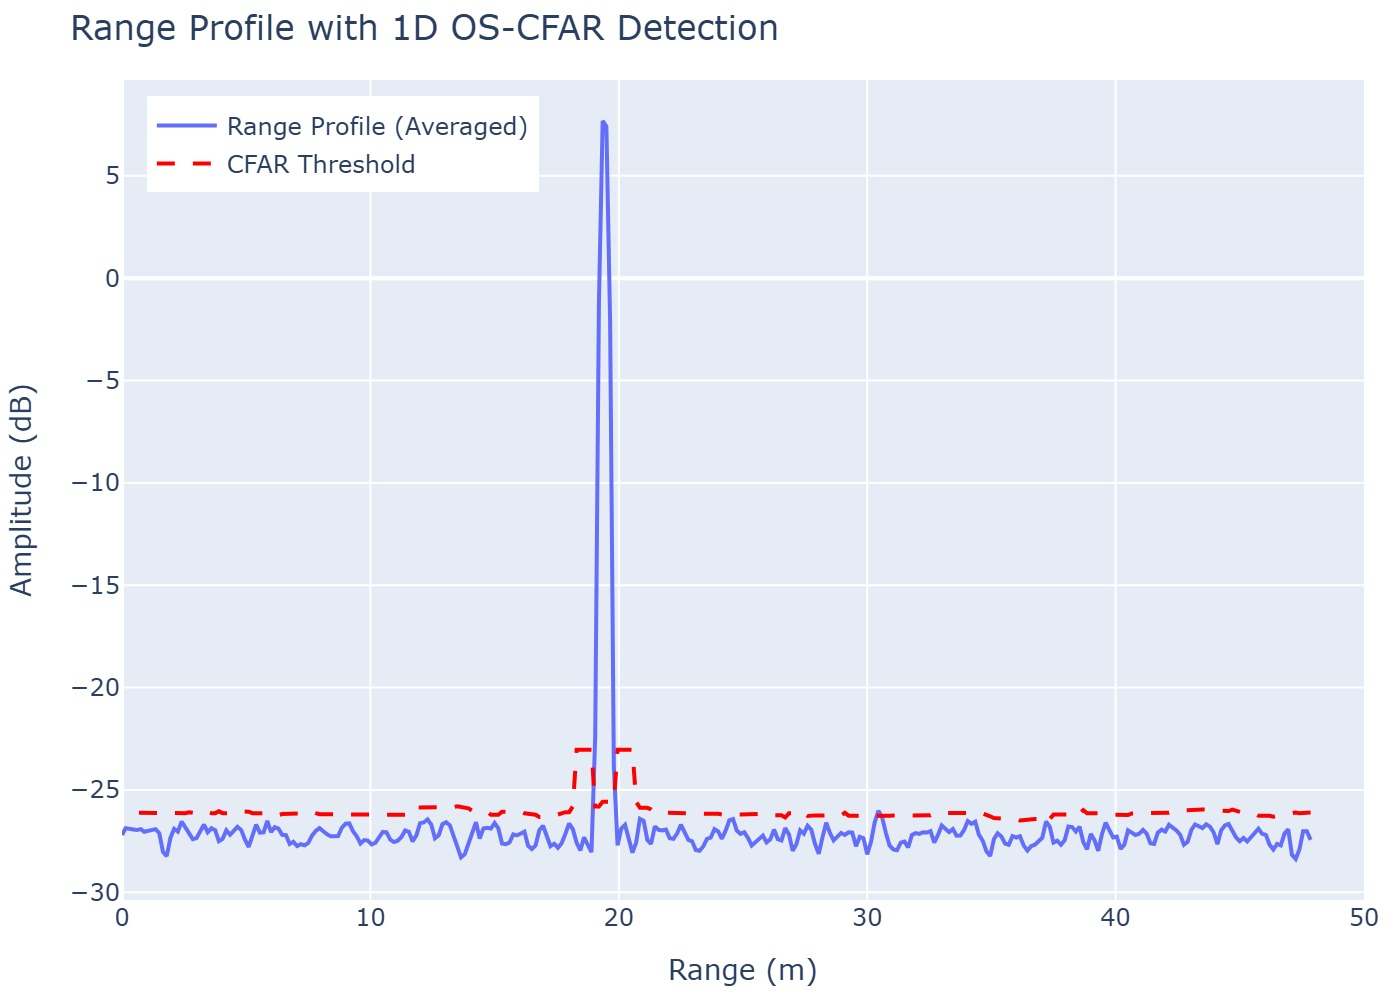

In [11]:
max_range = (
    3e8
    * radar.radar_prop["receiver"].bb_prop["fs"]
    * radar.radar_prop["transmitter"].waveform_prop["pulse_length"]
    / radar.radar_prop["transmitter"].waveform_prop["bandwidth"]
    / 2
)

# Range axis flipped because of down-chirp (61→60 GHz)
range_axis = np.flip(
    np.linspace(0, max_range, radar.sample_prop["samples_per_pulse"], endpoint=False)
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=range_axis,
        y=20 * np.log10(range_profile_avg[0, :]),
        name="Range Profile (Averaged)",
        line=dict(width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=range_axis,
        y=20 * np.log10(cfar),
        name="CFAR Threshold",
        line=dict(width=2, dash="dash", color="red"),
    )
)

fig.update_layout(
    title="Range Profile with 1D OS-CFAR Detection",
    yaxis=dict(title="Amplitude (dB)"),
    xaxis=dict(title="Range (m)", range=[0, 50]),
    height=500,
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=10, r=10, b=10, t=40),
)

show(fig)

### Angular Image Formation

The 320 virtual channels are reshaped into a `[64 × 128]` aperture (TX along Z, RX along Y). A 2D Hann window suppresses sidelobes, then a 1024×1024 2D FFT maps the aperture to a spatial frequency grid — effectively an azimuth × elevation image of all targets at the detected range.

In [14]:
# Import FFT functions
from scipy import fft
from scipy import signal

# Create 1D windows for angular FFT (50 dB sidelobe suppression)
win_el = signal.windows.chebwin(64, at=50)   # Elevation window (64 TX elements)
win_az = signal.windows.chebwin(128, at=50)  # Azimuth window (128 RX elements)

# Create 2D window matrix by outer product
# Applies window in both dimensions simultaneously
win_mat = np.tile(win_el[..., np.newaxis], (1, N_rx)) * np.tile(
    win_az[np.newaxis, ...], (N_tx, 1)
)

# Find detected range bins (where signal exceeds CFAR threshold)
det_idx = np.where(range_profile_avg > cfar)[1]

# Initialize 2D image spectrum
spec = np.zeros((1024, 1024))

# Process each detected range bin
for peak_idx in range(0, len(det_idx)):
    # Extract MIMO data for this range bin [8192 channels]
    raw_bv = range_profile[:, 0, det_idx[peak_idx]]

    # Initialize virtual array matrix [64 TX × 128 RX]
    bv = np.zeros((N_tx, N_rx), dtype=np.complex128)

    # Reshape MIMO channels to virtual array geometry
    # Data is organized as: [TX0-RX_all, TX1-RX_all, ..., TX63-RX_all]
    # Split into two TX sub-arrays and two RX sub-arrays
    half_tx = int(N_tx / 2)  # 32
    half_rx = int(N_rx / 2)  # 64
    
    # Map first TX sub-array (32 elements) to virtual array
    for t_idx in range(0, half_tx):
        # First RX sub-array (64 elements)
        bv[t_idx, 0:half_rx] = raw_bv[t_idx * N_rx : (t_idx * N_rx + half_rx)]
        # Second RX sub-array (64 elements)
        bv[t_idx, half_rx:] = raw_bv[
            int((t_idx + half_tx) * N_rx) : ((t_idx + half_tx) * N_rx + half_rx)
        ]

        # Map second TX sub-array (32 elements) to virtual array
        bv[t_idx + half_tx, 0:half_rx] = raw_bv[
            (t_idx * N_rx + half_rx) : (t_idx * N_rx + N_rx)
        ]
        bv[t_idx + half_tx, half_rx:] = raw_bv[
            int((t_idx + half_tx) * N_rx + half_rx) : int(
                (t_idx + half_tx) * N_rx + N_rx
            )
        ]
    
    # Apply 2D window to virtual array
    bv_windowed = bv[:, :] * win_mat
    
    # Compute 2D FFT for angular processing
    # Zero-pad to 1024×1024 for fine angular resolution
    # fftshift centers zero frequency
    angular_spectrum = np.abs(fft.fftshift(fft.fft2(bv_windowed, s=[1024, 1024])))
    
    # Take maximum across all range bins (brightest pixel projection)
    spec = np.maximum(spec, angular_spectrum)

### Imaging Result

The 2D map shows azimuth (Y-axis of virtual array) on the horizontal and elevation (Z-axis) on the vertical. Expect two bright spots from the spheres separated horizontally, and the half-ring producing an arc-shaped feature between them.

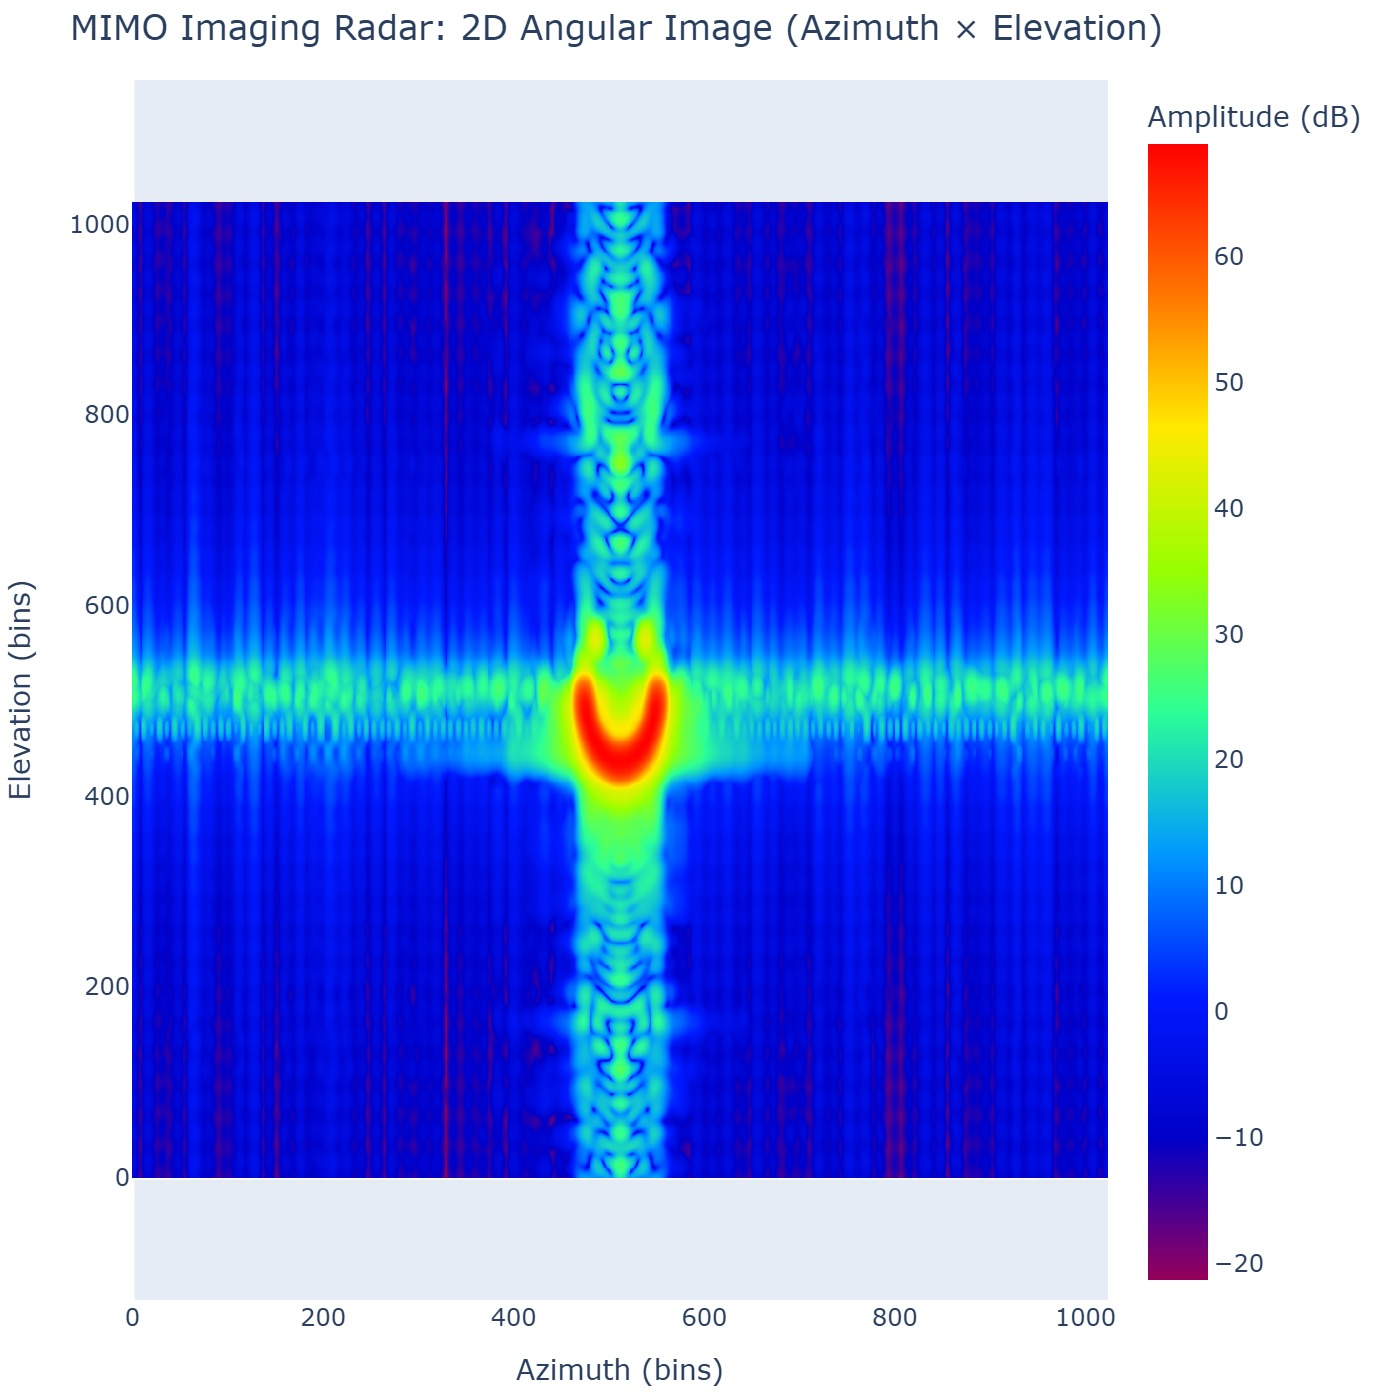

In [15]:
fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        z=20 * np.log10(spec),
        colorscale="Rainbow",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=20 * np.log10(np.max(spec)) - 40,
    )
)

fig.update_layout(
    title="MIMO Imaging Radar: 2D Angular Image (Azimuth × Elevation)",
    height=700,
    xaxis=dict(title="Azimuth (bins)", showgrid=False),
    yaxis=dict(title="Elevation (bins)", scaleanchor="x", scaleratio=1, showgrid=False),
    margin=dict(l=10, r=10, b=10, t=40),
)

show(fig)

## Summary

- A 64 TX × 128 RX MIMO array at 60.5 GHz synthesizes 8 192 virtual channels with ~0.9° angular resolution in both azimuth and elevation
- TDM waveform orthogonality separates TX contributions; coherent combination of all virtual channels provides the full 2D aperture
- Range FFT with 1D OS-CFAR isolates the 20 m target peak; the 2D angular FFT then maps each resolved point to its azimuth/elevation position
- The spheres (5.7° separation) and half-ring are clearly distinguishable in the final image, validating the virtual aperture resolution

### Things to Try

| Experiment | How |
|------------|-----|
| Reduce TX count | Change `num_tx` to 32 or 16; observe angular resolution degradation |
| Increase target separation | Move spheres further apart; note improved separation in image |
| Change FFT size | Adjust the 1024×1024 zero-pad; observe interpolation vs resolution |
| Narrow bandwidth | Reduce BW to 500 MHz (ΔR = 30 cm); targets at same range, no range separation change |
| Add noise | Lower RX gain; observe SNR impact on CFAR and image quality |
| Two-target range split | Place one sphere at 25 m; verify range + angle separation simultaneously |
